In [1]:
!pip install yfinance


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [89]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import timedelta


In [90]:
ticker = "RELIANCE.NS"
start_date = "2024-09-20"  
end_date = "2024-10-20"    
expiry_date = pd.to_datetime("2024-10-31")  
strike_price = 2600.0
default_r = 0.05  

In [91]:
stock_data = yf.download(ticker, start=start_date, end=end_date, interval="1d", progress=False)
stock_data.dropna(inplace=True)

if stock_data.empty:
    raise ValueError("No stock data found for the given ticker and time period. Please verify the ticker symbol and date range.")

# Compute daily returns
stock_data['Return'] = stock_data['Adj Close'].pct_change()

In [92]:
historical_data = yf.Ticker(ticker).history(period='1y')
historical_data.dropna(inplace=True)
sigma = historical_data['Close'].pct_change().std() * np.sqrt(252)  # Annualized volatility
mu = historical_data['Close'].pct_change().mean() * 252  

In [93]:
risk_free_data = yf.download("^IRX", start=start_date, end=end_date, interval="1d", progress=False)
risk_free_data.dropna(inplace=True)
stock_data = stock_data.merge(risk_free_data['Close'], left_index=True, right_index=True, how='left', suffixes=('', '_rf'))
stock_data['Close_rf'] = stock_data['Close_rf'].fillna(method='ffill') / 100  # Convert percentage to decimal

/var/folders/h4/_tysw9bj19jfy50whfr6dm240000gn/T/ipykernel_1704/252165006.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_data['Close_rf'] = stock_data['Close_rf'].fillna(method='ffill') / 100  # Convert percentage to decimal


In [94]:
def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("Invalid option type. Use 'call' or 'put'.")


In [95]:
def binomial_model(S, K, T, r, sigma, steps, option_type="call"):
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))  
    d = 1 / u  # Down factor
    q = 0.5 + (mu * np.sqrt(dt)) / (2 * sigma)  

    
    prices = np.zeros(steps + 1)
    prices[0] = S * (d ** steps)
    for i in range(1, steps + 1):
        prices[i] = prices[i - 1] * (u / d)

    
    values = np.maximum(0, (prices - K) if option_type == "call" else (K - prices))

    
    discount = np.exp(-r * dt)
    for step in range(steps - 1, -1, -1):
        values = discount * (q * values[1:step + 2] + (1 - q) * values[:step + 1])

    return values[0]


In [96]:
option_prices = []


for current_date, row in stock_data.iterrows():
    S_t = row['Close']
    
    
    r_t = row['Close_rf'] if not pd.isna(row['Close_rf']) else default_r
    
    T = (expiry_date - current_date).days / 365  
    if T < 0:
        
        option_price_bs = np.nan
        option_price_bin = np.nan
    else:
        
        option_price_bs = black_scholes(S=S_t, K=strike_price, T=T, r=r_t, sigma=sigma, option_type='call')
        option_price_bin = binomial_model(S=S_t, K=strike_price, T=T, r=r_t, sigma=sigma, steps=1000, option_type='call')
    
    option_prices.append({
        'Date': current_date,
        'Stock_Price': S_t,
        'BS_Call_Price': option_price_bs,
        'Binomial_Call_Price': option_price_bin
    })

option_prices_df = pd.DataFrame(option_prices)
option_prices_df.set_index('Date', inplace=True)

file_path = '/Users/apple/Desktop/reliance.csv'
reliance_actual_prices = pd.read_csv(file_path)
reliance_actual_prices.columns = reliance_actual_prices.columns.str.strip()  
reliance_actual_prices['DATE'] = pd.to_datetime(reliance_actual_prices['DATE'], format='%d-%b-%Y')

actual_option_prices = reliance_actual_prices[['DATE', 'CLOSE PRICE']]

option_prices_df = option_prices_df.reset_index()  
option_prices_df = option_prices_df.merge(actual_option_prices, left_on='Date', right_on='DATE', how='left')

final_columns = ['Date', 'Stock_Price',  
                 'BS_Call_Price', 'Binomial_Call_Price', 'CLOSE PRICE']

print(option_prices_df[final_columns])


         Date  Stock_Price  BS_Call_Price  Binomial_Call_Price  CLOSE PRICE
0  2024-09-20  2971.850098     387.494391           442.921235       461.50
1  2024-09-23  2986.750000     400.527764           452.554094       461.50
2  2024-09-24  2978.750000     392.220787           442.726199       461.50
3  2024-09-25  2987.899902     400.730054           450.157318       401.00
4  2024-09-26  2995.899902     408.124041           456.449563       419.00
5  2024-09-27  3052.350098     463.632560           511.717903       419.00
6  2024-09-30  2953.149902     364.416954           406.346216       410.00
7  2024-10-01  2929.649902     340.918854           381.037964       410.00
8  2024-10-03  2813.949951     229.582157           263.729215       255.60
9  2024-10-04  2773.050049     192.106117           223.252787       211.05
10 2024-10-07  2741.449951     161.999340           188.437063       185.65
11 2024-10-08  2794.699951     208.130215           235.821561       218.30
12 2024-10-0

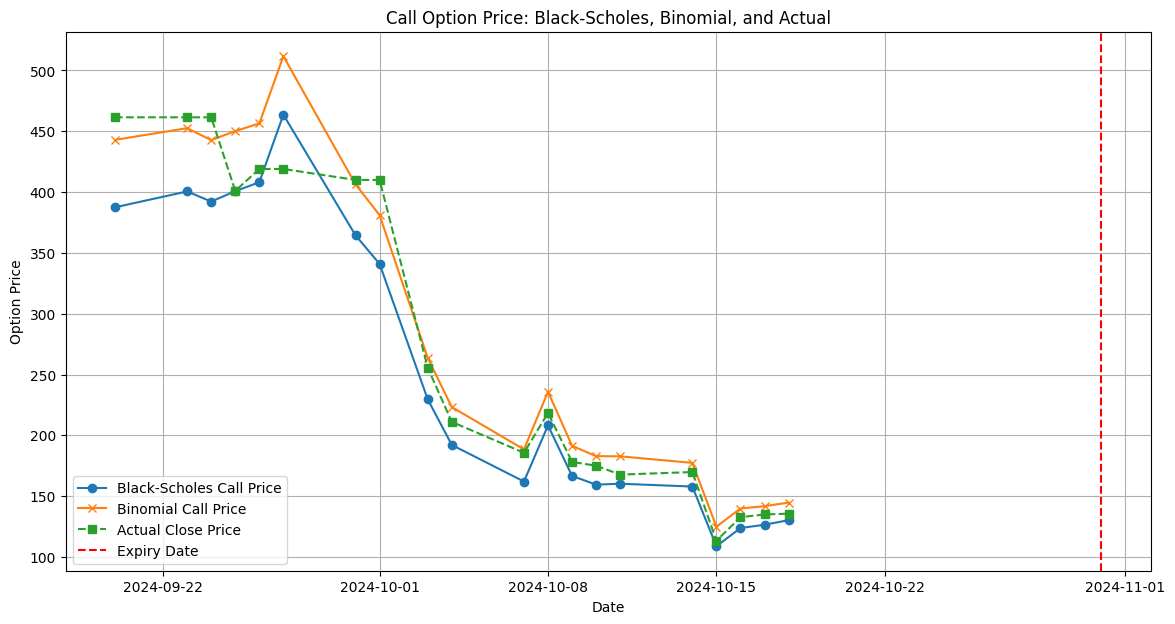

In [97]:
plt.figure(figsize=(14, 7))
plt.plot(option_prices_df['Date'], option_prices_df['BS_Call_Price'], label='Black-Scholes Call Price', marker='o')
plt.plot(option_prices_df['Date'], option_prices_df['Binomial_Call_Price'], label='Binomial Call Price', marker='x')
plt.plot(option_prices_df['Date'], option_prices_df['CLOSE PRICE'], label='Actual Close Price', linestyle='--', marker='s')
plt.axvline(x=expiry_date, color='red', linestyle='--', label='Expiry Date')
plt.xlabel('Date')
plt.ylabel('Option Price')
plt.title('Call Option Price: Black-Scholes, Binomial, and Actual')
plt.legend()
plt.grid(True)
plt.show()